# TF-IDF + LR / LinearSVC Baseline

1. Silver Set(30,000)의 review(content_norm)를 이용해 TF-IDF 벡터화 학습
    - 입력: content_norm
    - 출력: TF-IDF feature vector
2. Silver Set의 8개 coarse label을 대상으로
One-vs-Rest LinearSVC(Multi-label) 학습
3. Gold Set(500)에 대해 학습된 TF-IDF를 적용(transform)
4. 학습된 LinearSVC로 8개 coarse label 예측
5. 예측 결과와 Gold 정답 라벨 비교
6. 평가
    - Micro F1-score (주 지표)
    - Label-wise Precision / Recall / F1-score
    - Exact Match Ratio (보조 지표)

# [0] 라이브러리 설정 및 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### silver set

In [2]:
base_path = "/Users/gomdori/Documents/Git/fashion-review-complaint-detection/data"

row_silverset = pd.read_csv(os.path.join(base_path, "silverset.csv"))
print(f"row_silverset shape: {row_silverset.shape}")
print(f"row_silverset columns: {row_silverset.columns.tolist()}") 
row_silverset.head(3)

row_silverset shape: (30376, 50)
row_silverset columns: ['sample_id', 'split_hint', 'candidate_group', 'rating', 'content_norm', 'goods_name', 'brand_name', 'option_text', 'analysis_category', 'survey_size', 'survey_color', 'survey_thickness', 'survey_stretch', 'review_id', 'goods_no', 'fine_labels_str', 'coarse_labels_str', 'label_count', 'coarse_label_count', 'is_complaint', 'uncertain', 'manual_review_required', 'manual_review_reason', 'rationale', 'late_delivery', 'wrong_item', 'missing_item', 'damaged_on_arrival', 'packaging_issue', 'size_large', 'size_small', 'fit_dissatisfaction', 'finish_defect', 'durability', 'contamination', 'fabric_issue', 'thickness', 'poor_comfort', 'color_mismatch', 'design_mismatch', 'price_dissatisfaction', 'other_complaint', 'delivery', 'packaging', 'size_fit', 'quality', 'fabric_comfort', 'color_design', 'price', 'other_complaint_coarse']


,sample_id,split_hint,candidate_group,rating,content_norm,goods_name,brand_name,option_text,analysis_category,survey_size,...,price_dissatisfaction,other_complaint,delivery,packaging,size_fit,quality,fabric_comfort,color_design,price,other_complaint_coarse
0,cp_00001,silver_train_candidate,mixed_or_partial_rating4,4,.가격댜비 좋아요 33샀다가 커서 반츄하고 32가 있어 ㄱ 매했네요,스트레이트 셀비지 B32 데님 팬츠 로우,플랙,32,하의,조금 작음,...,0,0,0,0,1,0,0,0,0,0
1,cp_00002,silver_train_candidate,ambiguous_low_rating_topic_only,3,그냥 무난합니다 적당히 잘 쓸거 같아요~ 가격에 적합한 퀄인듯,펜타곤 포켓 빅사이즈 에코백 PP-108 블랙,세인트크루,프리,가방,NaN,...,0,0,0,0,0,0,0,0,0,0
2,cp_00003,silver_train_candidate,clear_complaint_low_rating,3,앞으로 조금 크긴 하지만 반사이즈정도 작게 신으면 아주 좋을 것 같아요!,유니 레더 독일군 HPMR6DA03M,슈펜,베이지 · 280,신발,조금 큼,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# row_silverset에 goldset이 섞여있으므로 제거 (silverset 저장 과정에서 goldset이 섞였음)
# split_hint == "silver_train_candidate"인 데이터만 사용

silverset = row_silverset[row_silverset["split_hint"] == "silver_train_candidate"]
print(f"silverset shape: {silverset.shape}")
print(f"silverset columns: {silverset.columns.tolist()}")
silverset.head(3)

silverset shape: (30000, 50)
silverset columns: ['sample_id', 'split_hint', 'candidate_group', 'rating', 'content_norm', 'goods_name', 'brand_name', 'option_text', 'analysis_category', 'survey_size', 'survey_color', 'survey_thickness', 'survey_stretch', 'review_id', 'goods_no', 'fine_labels_str', 'coarse_labels_str', 'label_count', 'coarse_label_count', 'is_complaint', 'uncertain', 'manual_review_required', 'manual_review_reason', 'rationale', 'late_delivery', 'wrong_item', 'missing_item', 'damaged_on_arrival', 'packaging_issue', 'size_large', 'size_small', 'fit_dissatisfaction', 'finish_defect', 'durability', 'contamination', 'fabric_issue', 'thickness', 'poor_comfort', 'color_mismatch', 'design_mismatch', 'price_dissatisfaction', 'other_complaint', 'delivery', 'packaging', 'size_fit', 'quality', 'fabric_comfort', 'color_design', 'price', 'other_complaint_coarse']


,sample_id,split_hint,candidate_group,rating,content_norm,goods_name,brand_name,option_text,analysis_category,survey_size,...,price_dissatisfaction,other_complaint,delivery,packaging,size_fit,quality,fabric_comfort,color_design,price,other_complaint_coarse
0,cp_00001,silver_train_candidate,mixed_or_partial_rating4,4,.가격댜비 좋아요 33샀다가 커서 반츄하고 32가 있어 ㄱ 매했네요,스트레이트 셀비지 B32 데님 팬츠 로우,플랙,32,하의,조금 작음,...,0,0,0,0,1,0,0,0,0,0
1,cp_00002,silver_train_candidate,ambiguous_low_rating_topic_only,3,그냥 무난합니다 적당히 잘 쓸거 같아요~ 가격에 적합한 퀄인듯,펜타곤 포켓 빅사이즈 에코백 PP-108 블랙,세인트크루,프리,가방,NaN,...,0,0,0,0,0,0,0,0,0,0
2,cp_00003,silver_train_candidate,clear_complaint_low_rating,3,앞으로 조금 크긴 하지만 반사이즈정도 작게 신으면 아주 좋을 것 같아요!,유니 레더 독일군 HPMR6DA03M,슈펜,베이지 · 280,신발,조금 큼,...,0,0,0,0,0,0,0,0,0,0


### gold set

In [4]:
base_path = "/Users/gomdori/Documents/Git/fashion-review-complaint-detection/data"
goldset = pd.read_csv(os.path.join(base_path, "goldset.csv"))
print(f"goldset shape: {goldset.shape}")
print(f"goldset columns: {goldset.columns.tolist()}")
goldset.head(3)

goldset shape: (500, 50)
goldset columns: ['gold_id', 'is_common_sample', 'assigned_to', 'candidate_group', 'rating', 'rating_num', 'content_norm', 'goods_name', 'brand_name', 'option_text', 'analysis_category', 'survey_size', 'survey_color', 'survey_thickness', 'survey_stretch', 'strong_complaint_matches', 'weak_topic_matches', 'risky_common_matches', 'positive_matches', 'has_contrast_marker', 'late_delivery', 'wrong_item', 'missing_item', 'damaged_on_arrival', 'packaging_issue', 'size_large', 'size_small', 'fit_dissatisfaction', 'finish_defect', 'durability', 'contamination', 'fabric_issue', 'thickness', 'poor_comfort', 'color_mismatch', 'design_mismatch', 'price_dissatisfaction', 'other_complaint', 'uncertain', 'labeler', 'label_notes', 'is_complaint_auto', 'coarse_labels_auto', 'review_id', 'goods_no', 'Unnamed: 45', 'label_notes.1', '의논여부', 'Unnamed: 48', 'cross_notes']


,gold_id,is_common_sample,assigned_to,candidate_group,rating,rating_num,content_norm,goods_name,brand_name,option_text,...,label_notes,is_complaint_auto,coarse_labels_auto,review_id,goods_no,Unnamed: 45,label_notes.1,의논여부,Unnamed: 48,cross_notes
0,G0001,0.0,member2,partial_complaint_in_rating5,5,5,타이트하게 꽉 핏인데 너무 마음에 들어요! 대신 소매가 좀 짧네요. 일상에서 편하게...,테크 1/2 집 긴팔 1328495-001,언더아머,L,...,NaN,NaN,NaN,83279458,2710158,NaN,NaN,NaN,NaN,NaN
1,G0002,NaN,member4,clear_non_complaint_rating5,5,5,사이즈 딱 좋고 질도 좋아 오래 입을수 있겠네요ㅎ 대만족입니다,바시티 숏 슬리브,에이치덱스,멜란지화이트 · XL,...,NaN,NaN,NaN,77483807,3894116,NaN,NaN,NaN,NaN,NaN
2,G0003,0.0,member5,partial_complaint_in_rating5,5,5,"재질도 쫀쫀하게 마감 잘 되있는 것 같고, 색감도 빈티지스럽게 너무 좋아요",월드클래스 피그먼트 맨투맨 티셔츠 네이비 FMT751,플루크,네이비 · M,...,NaN,NaN,NaN,83093053,3113692,NaN,NaN,NaN,NaN,NaN


### gold set coarse label 생성
- gold set은 팀원들이 라벨링한 정답지로, fine label로만 구성되어있기 때문에 상위 라벨인 coarse label을 생성해야함

In [5]:
# coarse label 생성
coarse_labels = [
    "delivery",
    "packaging",
    "size_fit",
    "quality",
    "fabric_comfort",
    "color_design",
    "price",
    "other_complaint_coarse",
]

# delivery
goldset["delivery"] = (
    goldset[
        [
            "late_delivery",
            "wrong_item",
            "missing_item",
            "damaged_on_arrival",
        ]
    ]
    .max(axis=1)
    .astype(int)
)

# packaging
goldset["packaging"] = goldset["packaging_issue"].astype(int)

# size_fit
goldset["size_fit"] = (
    goldset[
        [
            "size_large",
            "size_small",
            "fit_dissatisfaction",
        ]
    ]
    .max(axis=1)
    .astype(int)
)

# quality
goldset["quality"] = (
    goldset[
        [
            "finish_defect",
            "durability",
            "contamination",
        ]
    ]
    .max(axis=1)
    .astype(int)
)

# fabric_comfort
goldset["fabric_comfort"] = (
    goldset[
        [
            "fabric_issue",
            "thickness",
            "poor_comfort",
        ]
    ]
    .max(axis=1)
    .astype(int)
)

# color_design
goldset["color_design"] = (
    goldset[
        [
            "color_mismatch",
            "design_mismatch",
        ]
    ]
    .max(axis=1)
    .astype(int)
)

# price
goldset["price"] = goldset["price_dissatisfaction"].astype(int)

# other_complaint
goldset["other_complaint_coarse"] = (
    goldset["other_complaint"]
    .astype(int)
)

In [6]:
# coarse label별 complaint 개수 비교 (silverset vs goldset)
print("[silver coarse label distribution]")
print(silverset[coarse_labels].sum())

print("\n[Gold Coarse Label Distribution]")
print(goldset[coarse_labels].sum())

[silver coarse label distribution]
delivery                   652
packaging                  107
size_fit                  3635
quality                   2675
fabric_comfort            4778
color_design              2050
price                      389
other_complaint_coarse     395
dtype: int64

[Gold Coarse Label Distribution]
delivery                   15
packaging                   5
size_fit                  110
quality                    76
fabric_comfort            101
color_design               37
price                      17
other_complaint_coarse     11
dtype: int64


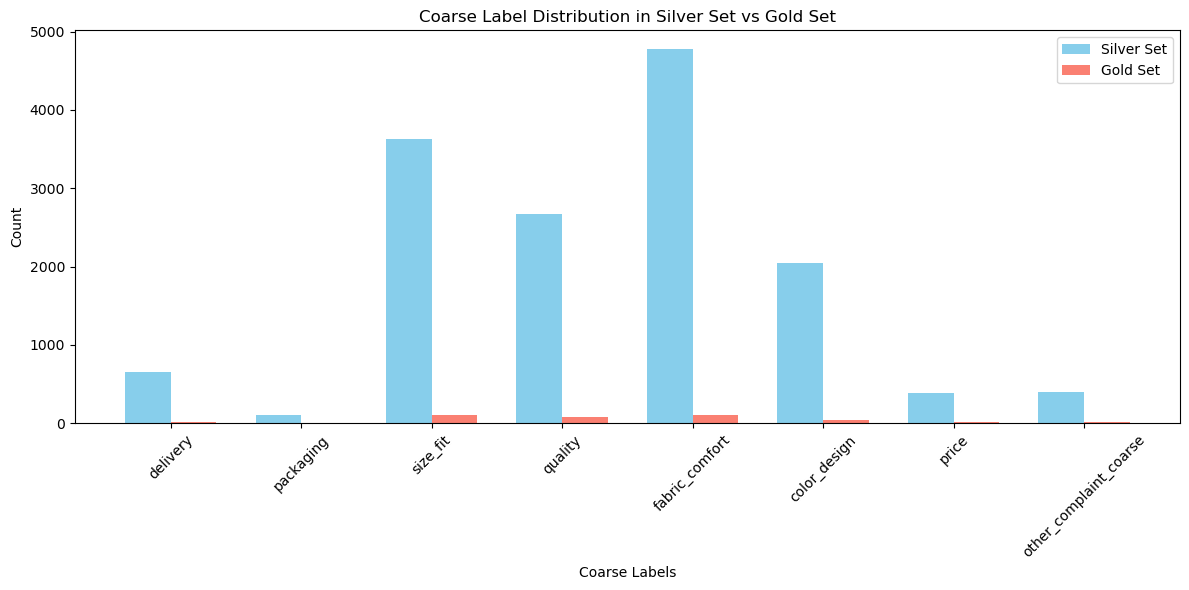

In [7]:
# 시각화
plt.figure(figsize=(12, 6))
x = np.arange(len(coarse_labels))
width = 0.35
plt.bar(x - width/2, silverset[coarse_labels].sum(), width
        , label='Silver Set', color='skyblue')
plt.bar(x + width/2, goldset[coarse_labels].sum(), width
        , label='Gold Set', color='salmon')
plt.xticks(x, coarse_labels, rotation=45)
plt.xlabel('Coarse Labels')
plt.ylabel('Count')
plt.title('Coarse Label Distribution in Silver Set vs Gold Set')
plt.legend()
plt.tight_layout()
plt.show()

# [1] TF-IDF Vectorization

train: silver set  
test: gold set

In [8]:
# 사용할 coarse label
coarse_labels = [
    "delivery",
    "packaging",
    "size_fit",
    "quality",
    "fabric_comfort",
    "color_design",
    "price",
    "other_complaint_coarse"
]

# train/test split
X_train_text = silverset["content_norm"].fillna("")
X_test_text = goldset["content_norm"].fillna("")

y_train = silverset[coarse_labels]
y_test = goldset[coarse_labels]


# TF-IDF 벡터화

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigram + bigram
    min_df=3,
    max_features=20000
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print(X_train.shape)
print(X_test.shape)

(30000, 20000)
(500, 20000)


# [2] Logistic Regression
### 실험 설정
- Train Set: Silver Set (30,000개)
- Test Set: Gold Set (500개)
- 입력 데이터: content_norm
- 벡터화: TF-IDF (ngram_range=(1,2))
- 분류기: One-vs-Rest Logistic Regression
- 평가 지표:
    - Micro F1-score (주 지표)
    - Precision / Recall / F1-score
    - Exact Match Ratio

## 2.1 Logistic Regression 학습

In [9]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

lr_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        random_state=42
    )
)

lr_model.fit(X_train, y_train)

,estimator,LogisticRegre...ndom_state=42)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42


## 2.2 gold set 예측 성능 - micro F1 score

In [10]:
# gold set에 대한 예측
lr_pred = lr_model.predict(X_test)

# 예측 결과 평가 (micro F1 score)
from sklearn.metrics import f1_score

micro_f1 = f1_score(
    y_test,
    lr_pred,
    average="micro"
)

print(f"Micro F1: {micro_f1:.4f}")

Micro F1: 0.3347


## 2.3 label-wise 성능 확인

In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=coarse_labels,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

              delivery       1.00      0.07      0.12        15
             packaging       0.00      0.00      0.00         5
              size_fit       0.75      0.19      0.30       110
               quality       0.88      0.30      0.45        76
        fabric_comfort       0.79      0.33      0.46       101
          color_design       0.33      0.03      0.05        37
                 price       0.00      0.00      0.00        17
other_complaint_coarse       0.00      0.00      0.00        11

             micro avg       0.79      0.21      0.33       372
             macro avg       0.47      0.11      0.17       372
          weighted avg       0.69      0.21      0.32       372
           samples avg       0.15      0.14      0.14       372



## 2.4 Exact Match Ratio

In [12]:
from sklearn.metrics import accuracy_score

exact_match = accuracy_score(
    y_test,
    lr_pred
)

print(f"Exact Match Ratio: {exact_match:.4f}")

Exact Match Ratio: 0.5420


# [3] LinearSVC

## 3.1 LinearSVC 모델 학습 및 예측

In [13]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

svc_model = OneVsRestClassifier(
    LinearSVC(
        random_state=42
    )
)

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

## 3.2 gold set 예측 성능 - micro F1 score

In [14]:
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score
)

micro_f1 = f1_score(
    y_test,
    svc_pred,
    average="micro"
)

print(f"[LinearSVC baseline]")
print(f"Micro F1: {micro_f1:.4f}")

[LinearSVC baseline]
Micro F1: 0.5396


## 3.3 label-wise 성능 확인

In [15]:
print(
    classification_report(
        y_test,
        svc_pred,
        target_names=coarse_labels,
        zero_division=0
    )
)

                        precision    recall  f1-score   support

              delivery       0.75      0.60      0.67        15
             packaging       1.00      0.40      0.57         5
              size_fit       0.66      0.42      0.51       110
               quality       0.72      0.64      0.68        76
        fabric_comfort       0.60      0.56      0.58       101
          color_design       0.37      0.27      0.31        37
                 price       0.57      0.24      0.33        17
other_complaint_coarse       0.00      0.00      0.00        11

             micro avg       0.62      0.48      0.54       372
             macro avg       0.58      0.39      0.46       372
          weighted avg       0.61      0.48      0.53       372
           samples avg       0.27      0.26      0.26       372



## 2.4 Exact Match Ratio

In [16]:
exact_match = accuracy_score(
    y_test,
    svc_pred
)

print(f"Exact Match Ratio: {exact_match:.4f}")

Exact Match Ratio: 0.5500


# [4] Baseline 비교

## 4.1 모델별 핵심 지표 비교

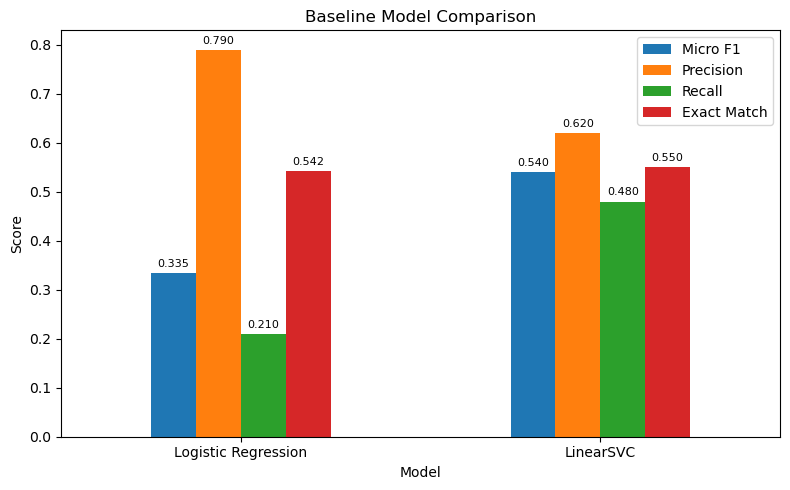

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "LinearSVC"],
    "Micro F1": [0.3347, 0.5396],
    "Precision": [0.79, 0.62],
    "Recall": [0.21, 0.48],
    "Exact Match": [0.542, 0.550]
})

ax = comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

# bar 위에 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=3
    )

plt.legend(loc="best")
plt.tight_layout()

# 시각화 결과 저장
plt.savefig(
    "../outputs/baseline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.2 label별 f1 score 비교

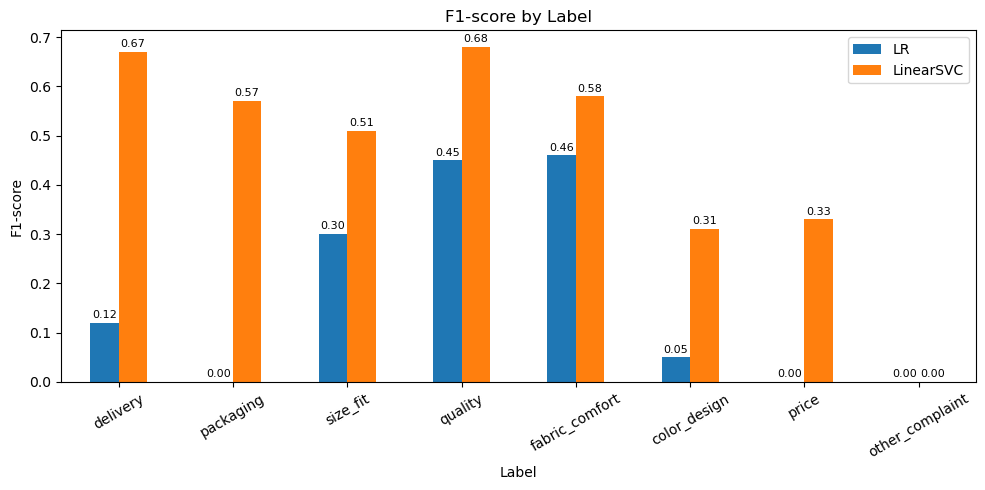

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

label_f1 = pd.DataFrame({
    "Label": [
        "delivery",
        "packaging",
        "size_fit",
        "quality",
        "fabric_comfort",
        "color_design",
        "price",
        "other_complaint"
    ],
    "LR": [
        0.12,
        0.00,
        0.30,
        0.45,
        0.46,
        0.05,
        0.00,
        0.00
    ],
    "LinearSVC": [
        0.67,
        0.57,
        0.51,
        0.68,
        0.58,
        0.31,
        0.33,
        0.00
    ]
})

ax = label_f1.set_index("Label").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("F1-score by Label")
plt.ylabel("F1-score")
plt.xticks(rotation=30)

# bar 위에 수치 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()

# 시각화 결과 저장
plt.savefig(
    "../outputs/f1_by_label.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()